/tmp/ipykernel_3180/497604479.py:24: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  return torch.tensor(X, dtype=torch.float32).unsqueeze(-1), torch.tensor(y, dtype=torch.float32).unsqueeze(-1)


Epoch [20/100], Loss: 0.4504
Epoch [40/100], Loss: 0.2829
Epoch [60/100], Loss: 0.0971
Epoch [80/100], Loss: 0.0834
Epoch [100/100], Loss: 0.0730


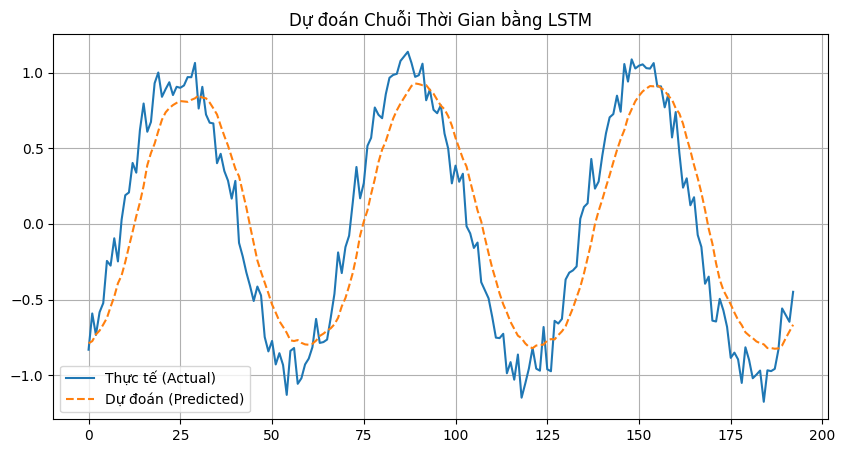

In [1]:
#Bai 1
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Tạo dữ liệu giả lập chuỗi thời gian (ví dụ: hàm sin + nhiễu)
np.random.seed(42)
t = np.linspace(0, 100, 1000)
data = np.sin(t) + np.random.normal(0, 0.1, len(t))

# Chia train/test (80/20)
train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]

# 2. Hàm tạo Dataset với window_size = 7
def create_dataset(sequence, window_size=7):
    X, y = [], []
    for i in range(len(sequence) - window_size):
        X.append(sequence[i : i + window_size])
        y.append(sequence[i + window_size])
    return torch.tensor(X, dtype=torch.float32).unsqueeze(-1), torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

window_size = 7
X_train, y_train = create_dataset(train_data, window_size)
X_test, y_test = create_dataset(test_data, window_size)

# 3. Định nghĩa mô hình LSTM
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, output_size=1):
        super(LSTMForecaster, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # LSTM trả về (output, (h_n, c_n))
        out, (h_n, c_n) = self.lstm(x)
        # Lấy hidden state của bước cuối cùng: h_n có shape (1, batch, hidden_size)
        return self.fc(h_n.squeeze(0))

# 4. Huấn luyện mô hình
model = LSTMForecaster()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 100
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

# 5. Đánh giá và Vẽ biểu đồ
model.eval()
with torch.no_grad():
    predictions = model(X_test).numpy()

plt.figure(figsize=(10, 5))
plt.plot(y_test.numpy(), label='Thực tế (Actual)')
plt.plot(predictions, label='Dự đoán (Predicted)', linestyle='--')
plt.title('Dự đoán Chuỗi Thời Gian bằng LSTM')
plt.legend()
plt.grid(True)
plt.show()

In [2]:
#Bai 2
# Giả định tập dữ liệu đã được số hóa (tokenized & padded) thành X_train
# Giả sử: embed_dim = 8, hidden_dim = 16, num_classes = 2, vocab_size = 500

class BidirectionalSentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super(BidirectionalSentimentLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        # Thiết lập bidirectional=True
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        # Vì là Bidirectional nên đầu vào của lớp FC sẽ gấp đôi hidden_dim
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x, lengths):
        embedded = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)

        # h_n có shape: (num_layers * num_directions, batch, hidden_dim)
        _, (h_n, _) = self.lstm(packed)

        # Lấy hidden state của chiều xuôi (h_n[-2]) và chiều ngược (h_n[-1]) rồi nối lại
        forward_hidden = h_n[-2]
        backward_hidden = h_n[-1]
        combined_hidden = torch.cat([forward_hidden, backward_hidden], dim=1) # shape: (batch, hidden_dim * 2)

        return self.fc(combined_hidden)

# Khởi tạo mô hình thử nghiệm
vocab_size = 100
model_bidi = BidirectionalSentimentLSTM(vocab_size=vocab_size, embed_dim=8, hidden_dim=16, num_classes=2)
print(model_bidi)

BidirectionalSentimentLSTM(
  (embedding): Embedding(100, 8)
  (lstm): LSTM(8, 16, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=32, out_features=2, bias=True)
)


In [3]:
#Bai 3
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# 1. Chuẩn bị dữ liệu văn bản mẫu (Ví dụ một đoạn văn ngắn)
text = "tram nam trong coi nguoi ta chu tai chu menh kheo la ghet nhau trai qua mot cuoc be dau nhung dieu trong thay ma dau don long"

# Tạo Vocab ký tự
chars = sorted(list(set(text)))
vocab_size = len(chars)
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

# 2. Tạo dữ liệu train: input seq_length = 50, target là ký tự thứ 51
seq_length = 50
data_X = []
data_y = []

for i in range(0, len(text) - seq_length):
    seq_in = text[i : i + seq_length]
    seq_out = text[i + seq_length]
    data_X.append([char_to_idx[ch] for ch in seq_in])
    data_y.append(char_to_idx[seq_out])

X_train = torch.tensor(data_X, dtype=torch.long)
y_train = torch.tensor(data_y, dtype=torch.long)

# 3. Build LSTM mạng 2 tầng (num_layers=2), hidden_size = 128
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, hidden_size=128, num_layers=2):
        super(CharLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, 32)
        self.lstm = nn.LSTM(32, hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        embedded = self.embedding(x)
        out, _ = self.lstm(embedded)
        # Lấy output của bước thời gian cuối cùng để dự đoán ký tự tiếp theo
        out = out[:, -1, :]
        return self.fc(out)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CharLSTM(vocab_size).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.002)

# 4. Huấn luyện mô hình (Train 50-100 epoch)
X_train, y_train = X_train.to(device), y_train.to(device)
epochs = 100
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train)
    loss = criterion(logits, y_train)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}/100 - Loss: {loss.item():.4f}")

# 5. Hàm sinh văn bản bằng kỹ thuật Temperature Sampling
def generate_text(model, seed_str, gen_length=50, temperature=0.7):
    model.eval()
    generated = seed_str

    with torch.no_grad():
        for _ in range(gen_length):
            # Format chuỗi seed thành tensor đầu vào (chỉ lấy đúng seq_length ký tự cuối cùng)
            input_seq = [char_to_idx[ch] for ch in generated[-seq_length:] if ch in char_to_idx]
            if len(input_seq) < seq_length:
                # Nếu chuỗi seed ngắn hơn seq_length thì pad thêm số 0 vào trước
                input_seq = [0]*(seq_length - len(input_seq)) + input_seq

            x = torch.tensor([input_seq], dtype=torch.long).to(device)

            # Predict
            logits = model(x)

            # Áp dụng Temperature Sampling
            probs = torch.softmax(logits / temperature, dim=1).squeeze().cpu().numpy()

            # Chọn ký tự ngẫu nhiên theo phân phối xác suất
            next_idx = np.random.choice(len(probs), p=probs)
            next_char = idx_to_char[next_idx]

            generated += next_char

    return generated

# Thử nghiệm sinh văn bản với seed cho trước
seed = "tram nam trong coi nguoi ta chu tai chu menh kheo la "
print("\n--- Kết quả sinh văn bản tự động ---")
print(generate_text(model, seed, gen_length=40, temperature=0.6))

Epoch  20/100 - Loss: 2.2539
Epoch  40/100 - Loss: 0.8259
Epoch  60/100 - Loss: 0.1504
Epoch  80/100 - Loss: 0.0405
Epoch 100/100 - Loss: 0.0207

--- Kết quả sinh văn bản tự động ---
tram nam trong coi nguoi ta chu tai chu menh kheo la ghet nhau trai qua mot cuoc be dau nhung
